In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

In [75]:
IS_SLIPPERY = True

## Approach: Q-learning

In [76]:
class QL:
  def __init__(self, observation_space_size: int, action_space_size: int, alpha = 0.9, gamma = 0.9, epsilon = 1, epsilon_decay = 0.0001) -> None:
    self.alpha = alpha # learning rate
    self.gamma = gamma # discount factor
    self.epsilon = epsilon # epsilon greedy start
    self.epsilon_decay = epsilon_decay # epsilon greedy decay
    self.q = np.zeros((observation_space_size, action_space_size))
    self.rng = np.random.default_rng()

  def train(self, env, n_episodes = 100):
    total_rewards = np.zeros(n_episodes, dtype=np.float32)
    for ep in range(n_episodes):
      total_rewards[ep] = self._train_step(env)
    return total_rewards

  def _train_step(self, env: gym.Env):
    state = env.reset()[0]
    episode_over = False
    reward = 0
    while not (episode_over):
      action = self._choose_action_train(env, state)
      new_state, reward, terminated, truncated, _info = env.step(action)
      self._q_update(state, action, reward, new_state)
      episode_over = terminated or truncated
      state = new_state
    self.epsilon = max(self.epsilon - self.epsilon_decay, 0)
    return float(reward)

  def _q_update(self, state, action, reward, new_state):
    self.q[state,action] = self.q[state,action] + self.alpha * (
      reward + self.gamma * np.max(self.q[new_state,:]) - self.q[state,action]
    )

  def _choose_action_train(self, env: gym.Env, state):
    if self.rng.random() < self.epsilon:
      return env.action_space.sample()
    else:
      return np.argmax(self.q[state, :])

  def choose_action(self, state):
    return np.argmax(self.q[state, :])

  def load_model(self, path:str) -> None:
    self.q = np.load(path)

  def save_model(self, path:str, q: np.ndarray) -> None:
    np.save(path, self.q)

In [77]:
N_EPISODES = 10000

env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=IS_SLIPPERY, render_mode=None)
ql = QL(env.observation_space.n, env.action_space.n)
rewards = ql.train(env, N_EPISODES)

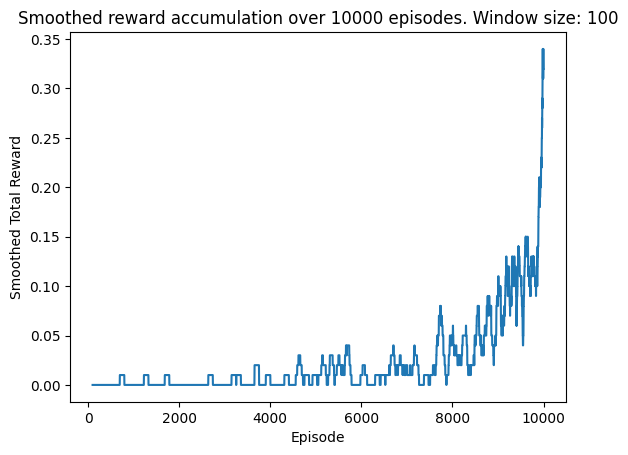

In [80]:
window_size = 100
rolling_rewards = pd.Series(rewards).rolling(window=window_size).mean()
plt.plot(rolling_rewards)
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title(f"Smoothed reward accumulation over {N_EPISODES} episodes. Window size: {window_size}")
plt.show()

In [79]:
N_TEST_RUNS = 100
RENDER = None # set to "human" to enable game UI

env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=IS_SLIPPERY, render_mode=RENDER)
test_reward = 0
for _ in range(N_TEST_RUNS):
  terminated = False
  truncated = False
  state = env.reset()[0]
  while not(terminated or truncated):
    state, r, terminated, truncated, _i = env.step(ql.choose_action(state))
    test_reward += float(r)
print(f"{N_TEST_RUNS} games played")
print(f"Average reward per game: {test_reward/N_TEST_RUNS}")

100 games played
Average reward per game: 0.45
